# 0 - Import and Load Data

In [25]:
from pyspark.sql import SparkSession
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown as md
import matplotlib.ticker as mtick

from pyspark.sql.functions import (
    col, count, countDistinct, min, max,
    isnan, when, year, avg, to_date, lit, expr
)
from pyspark.sql.functions import sum as spark_sum


In [2]:
spark = SparkSession.builder \
    .appName("SpotifyAnalysis") \
    .master("local[4]") \
    .getOrCreate()

25/12/13 18:55:56 WARN Utils: Your hostname, bruno-rocha-Inspiron-7580 resolves to a loopback address: 127.0.1.1; using 192.168.0.207 instead (on interface wlp3s0)
25/12/13 18:55:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/13 18:55:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
file_path = str(Path.cwd().parent / 'data' / 'charts.csv')

df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(file_path)

In [4]:
spark.sparkContext.setLogLevel("ERROR")

# 1 - Explore and Data Analysis

## 1.1 Basics, Data Quality & Structure

In [5]:
df.show(3)

+--------------------+----+----------+------------+--------------------+---------+------+-------------+-------+
|               title|rank|      date|      artist|                 url|   region| chart|        trend|streams|
+--------------------+----+----------+------------+--------------------+---------+------+-------------+-------+
|Chantaje (feat. M...|   1|2017-01-01|     Shakira|https://open.spot...|Argentina|top200|SAME_POSITION| 253019|
|Vente Pa' Ca (fea...|   2|2017-01-01|Ricky Martin|https://open.spot...|Argentina|top200|      MOVE_UP| 223988|
|Reggaetón Lento (...|   3|2017-01-01|        CNCO|https://open.spot...|Argentina|top200|    MOVE_DOWN| 210943|
+--------------------+----+----------+------------+--------------------+---------+------+-------------+-------+
only showing top 3 rows



In [6]:
# datas que não são datas
df.filter(~col("date").rlike(r"^\d{4}-\d{2}-\d{2}$")) \
  .select("date") \
  .distinct() \
  .show(7, truncate=False)


+--------------+
|date          |
+--------------+
|188           |
|26            |
|6             |
| Tulsi Kumar)"|
|41            |
|38            |
|191           |
+--------------+
only showing top 7 rows



In [7]:
df = df.withColumn(
    "date_clean",
    to_date(col("date"), "yyyy-MM-dd")
)
df.select(
    min("date_clean").alias("start_date"),
    max("date_clean").alias("end_date")
).show()

+----------+----------+
|start_date|  end_date|
+----------+----------+
|2017-01-01|2021-12-31|
+----------+----------+



In [8]:
df.select(
    countDistinct("title").alias("songs"),
    countDistinct("artist").alias("artists"),
    countDistinct("region").alias("regions"),
    countDistinct("date").alias("dates")
).show()


+------+-------+-------+-----+
| songs|artists|regions|dates|
+------+-------+-------+-----+
|164807|  96951|    208| 2011|
+------+-------+-------+-----+



## 1.2 Analysis by Region

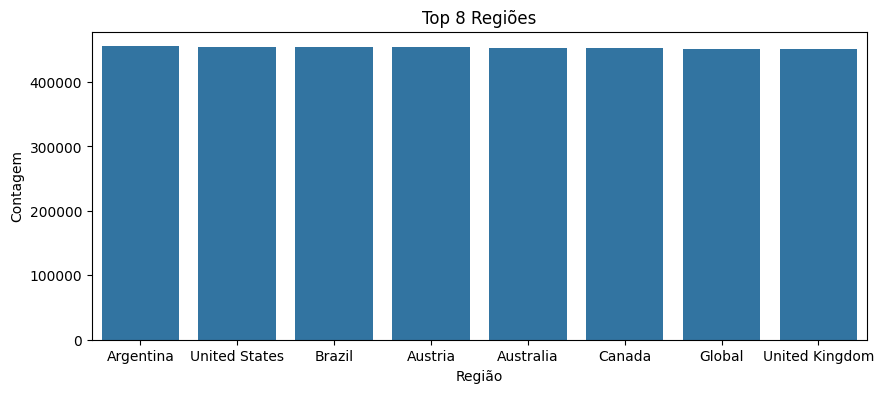

In [9]:
from pyspark.sql.functions import col

region_df = (
    df.groupBy("region")
      .count()
      .orderBy(col("count").desc())
      .limit(8)
      .toPandas()
)

plt.figure(figsize=(10,4))
sns.barplot(data=region_df, x="region", y="count")
plt.title("Top 8 Regiões")
plt.xlabel("Região")
plt.ylabel("Contagem")
plt.show()

In [10]:
top1 = (
    df.filter(col("rank") == 1)
      .groupBy("title", "artist")
      .count()
      .orderBy(col("count").desc())
      .limit(10)
      .toPandas()
)

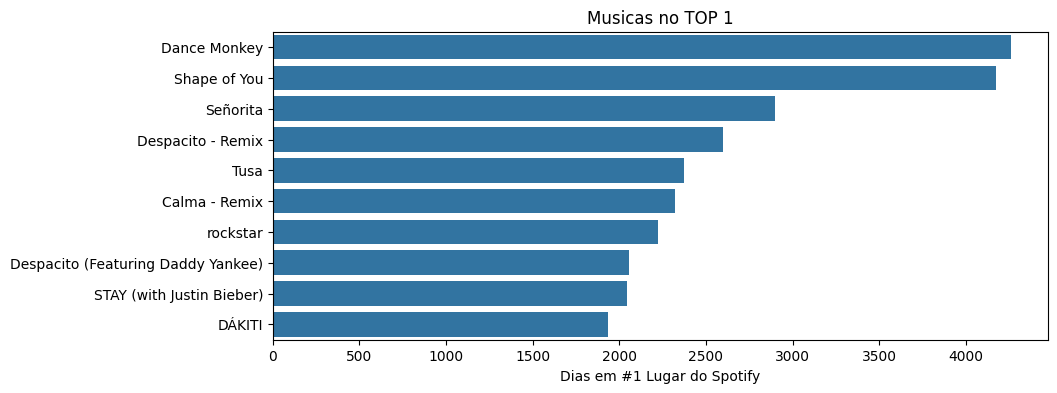

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(data=top1, y="title", x="count")
plt.title("Dias no TOP 1 (músicas)")
plt.xlabel("Dias em #1 Lugar do Spotify")
plt.ylabel("")
plt.show()

In [12]:
df = df.withColumn('streams', expr("try_cast(streams as double)"))
top_streams = (
    df.groupBy("title", "artist")
      .sum("streams")
      .orderBy(col("sum(streams)").desc())
      .limit(10)
      .toPandas()
)

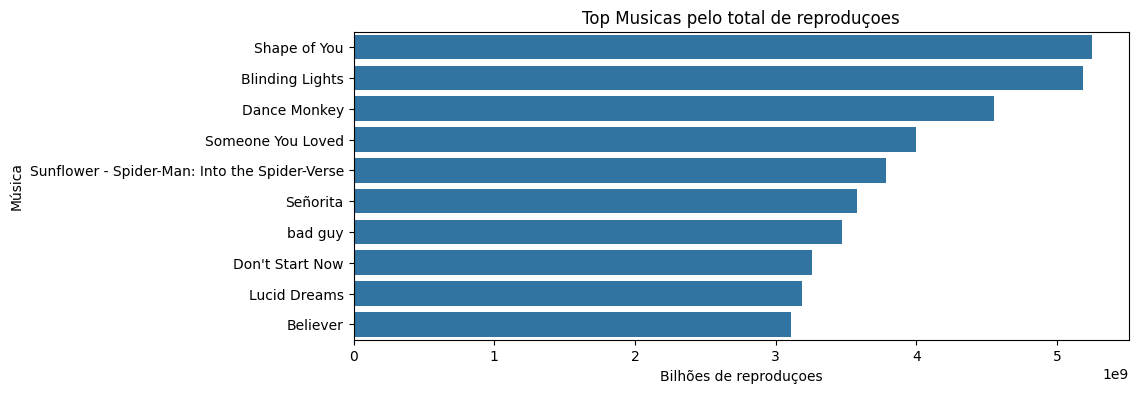

In [13]:
plt.figure(figsize=(10,4))
sns.barplot(data=top_streams, y="title", x="sum(streams)")
plt.title("Top Musicas pelo total de reproduçoes")
plt.xlabel("Bilhões de reproduçoes")
plt.ylabel("Música")
plt.show()

In [14]:
yearly_top = (
    df.withColumn("year", year("date"))
      .groupBy("year", "title")
      .sum("streams")
      .withColumnRenamed("sum(streams)", "streams")
)

windowed = yearly_top.orderBy(col("streams").desc())

yearly_pd = windowed.toPandas()

top3_per_year = (
    yearly_pd
    .sort_values(["year", "streams"], ascending=[True, False])
    .groupby("year")
    .head(3)
)

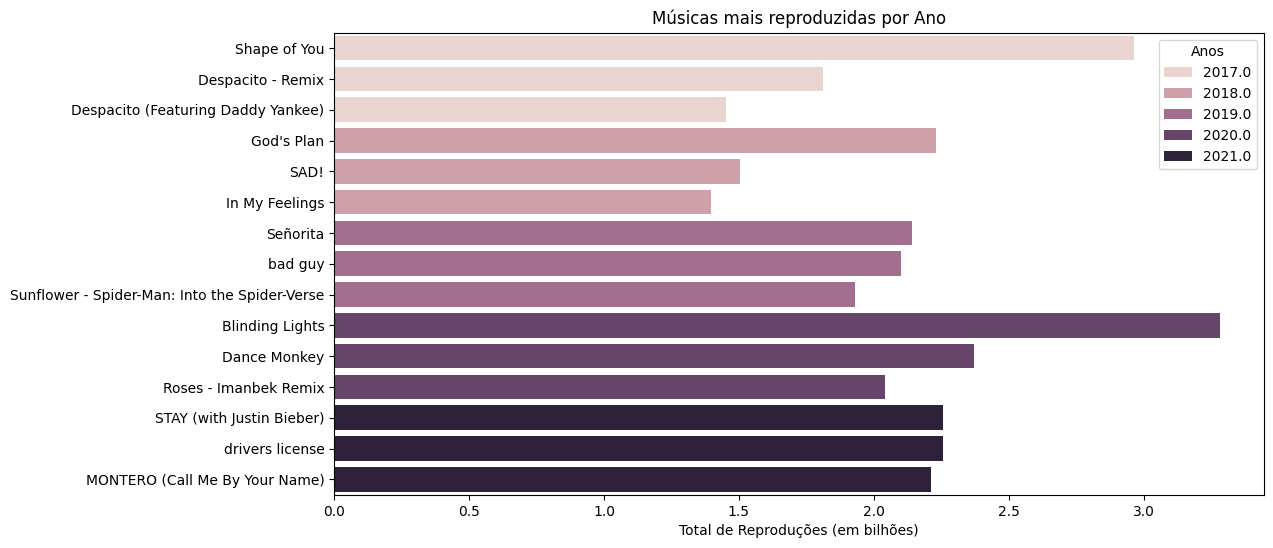

In [51]:
def billions(x, pos):
    return f'{x/1e9:.1f}'

plt.figure(figsize=(12,6))
sns.barplot(
    data=top3_per_year,
    x="streams",
    y="title",
    hue="year"
)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(billions))

plt.title("Músicas mais reproduzidas por Ano")
plt.xlabel("Total de Reproduções (em bilhões)")
plt.ylabel("")
plt.legend(title="Anos")
plt.show()



In [ ]:
artist_streams = (
    df.groupBy("artist")
      .sum("streams")
      .orderBy(col("sum(streams)").desc())
      .limit(10)
      .toPandas()
)

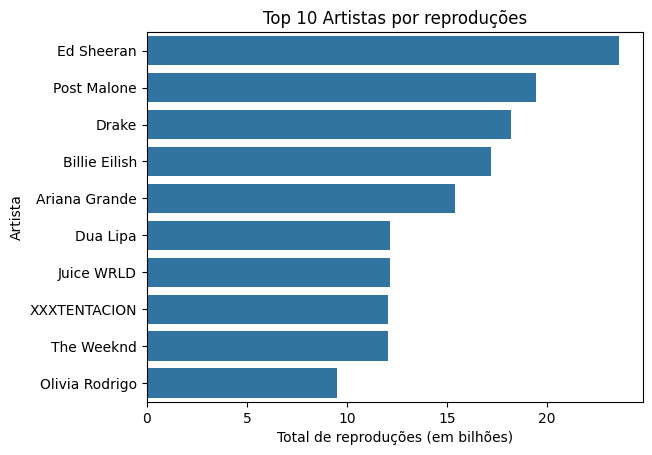

In [ ]:
sns.barplot(data=artist_streams, y="artist", x="sum(streams)")

plt.title("Top 10 Artistas por reproduções")
plt.xlabel("Total de reproduções (em bilhões)")
plt.ylabel("Artista")

plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(billions))

plt.show()


In [40]:
streams_by_year = (
    df.withColumn("year", year("date"))
      .groupBy("year")
      .agg(spark_sum("streams").alias("total_streams"))
      .orderBy("year")
)
streams_by_year_pd = streams_by_year.toPandas()


In [45]:
streams_by_year_pd["yoy_growth_pct"] = (
    streams_by_year_pd["total_streams"]
    .pct_change() * 100
)

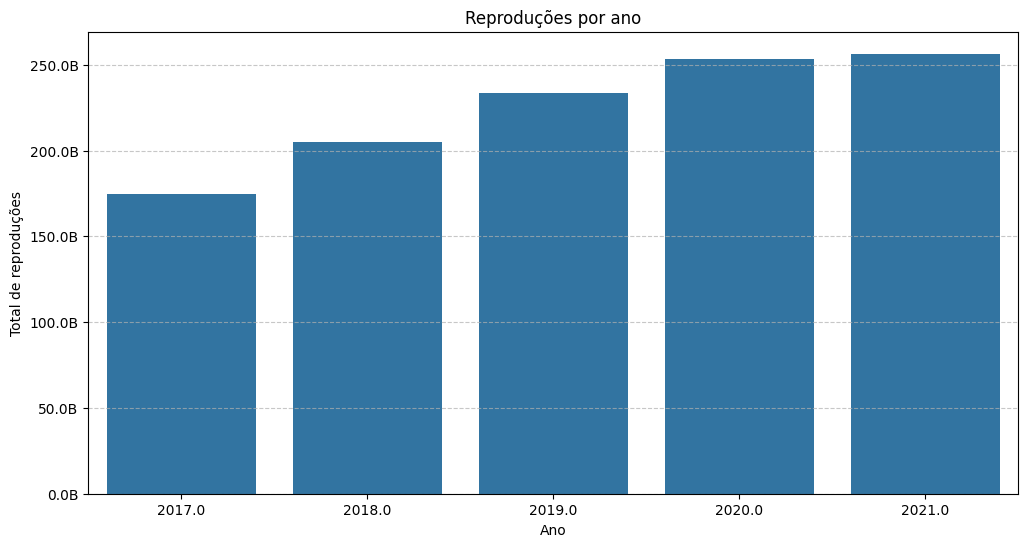

In [52]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=streams_by_year_pd,
    x="year",
    y="total_streams"
)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
)

plt.gca().xaxis.set_major_locator(mtick.MaxNLocator(integer=True))

plt.title("Reproduções por ano")
plt.xlabel("Ano")
plt.ylabel("Total de reproduções")
plt.grid(axis="y", linestyle="--", alpha=0.7)



plt.show()


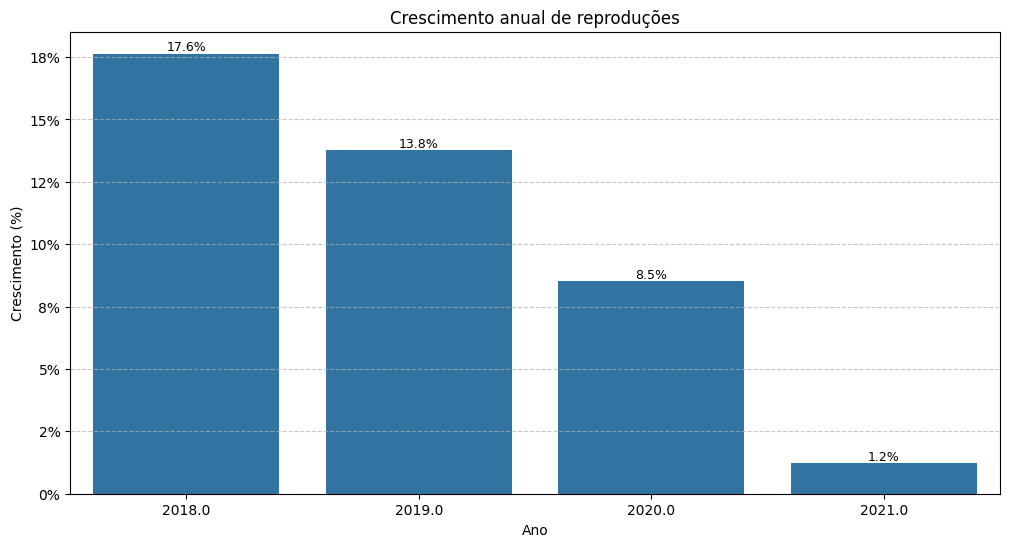

In [ ]:
yoy_df = streams_by_year_pd.dropna(subset=["yoy_growth_pct"])

plt.figure(figsize=(12,6))

sns.barplot(
    data=yoy_df,
    x="year",
    y="yoy_growth_pct"
)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x:.0f}%')
)

plt.gca().xaxis.set_major_locator(mtick.MaxNLocator(integer=True))
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x:.0f}%')
)
plt.title("Crescimento anual de reproduções")
plt.xlabel("Ano")
plt.ylabel("Crescimento (%)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

for i, v in enumerate(yoy_df["yoy_growth_pct"]):
    plt.text(
        i,
        v,
        f"{v:.1f}%",
        ha="center",
        va="bottom" if v >= 0 else "top",
        fontsize=9
    )


plt.show()
